In [107]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# import h5py
import glob

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

In [121]:
fit = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155_l2m2/mtot72/220+210_SXS_BBH_1155_l2m2_fmin10Hz_ppSNR20_mtot72_edgeon/engine/1126259462.423000/config.ini')

In [122]:
fit.antenna_patterns

{'H1': (0.5731858962316518, -0.4585449256465797),
 'L1': (-0.5248827809483454, 0.21204804084967172)}

In [123]:
wd = fit.whiten(fit.analysis_data)
cumsnr = {i: np.sqrt(np.cumsum(d*d)) for i, d in wd.items()}
ppSNR = float(np.linalg.norm([cs.iloc[-1] for cs in cumsnr.values()]))
snr_scale = ppSNR / 20
print(ppSNR)
print(snr_scale)

19.99999999999747
0.9999999999998735


In [112]:
light_inj = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155_l2m2/mtot72/*_H1.hdf5')
heavy_inj = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155_l2m2/mtot330/*_H1.hdf5')

In [113]:
light_inj_all = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot72/*_H1.hdf5')
heavy_inj_all = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot330/*_H1.hdf5')

In [114]:
light_dfs = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(light_inj)}

heavy_dfs = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(heavy_inj)}

In [115]:
light_dfs_all = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(light_inj_all)}

heavy_dfs_all = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(heavy_inj_all)}

In [116]:
res_df = light_dfs['faceon'] - light_dfs['inclined']

(1126259462.397878, 1126259462.472878)

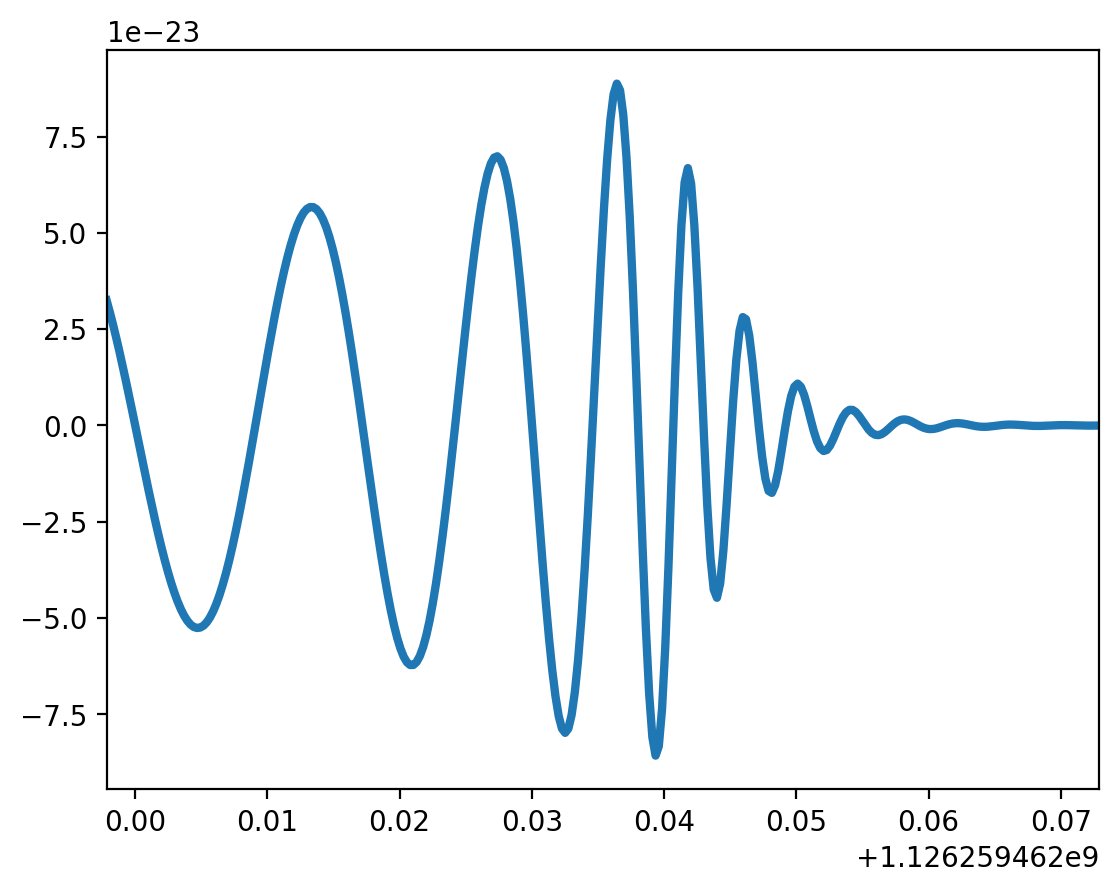

In [117]:
plt.plot(res_df, lw=3)
plt.xlim(np.median(res_df.index.values)-0.025, np.median(res_df.index.values)+0.05)

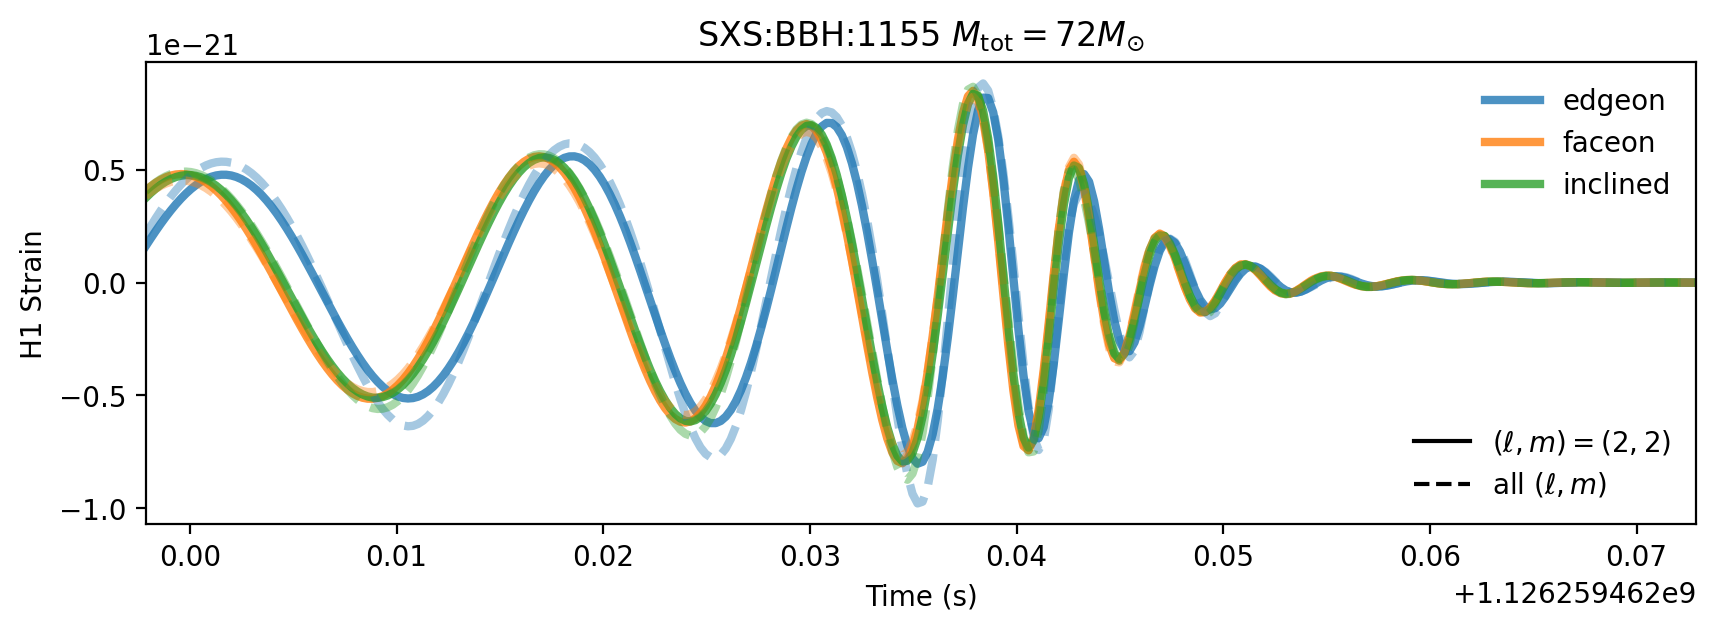

In [120]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (inc, df) in enumerate(light_dfs.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=inc)
for i, (inc, df) in enumerate(light_dfs_all.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.4, ls='--')

ax.set_xlim(np.median(df.index.values)-0.025, np.median(df.index.values)+0.05)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('SXS:BBH:1155 $M_{\mathrm{tot}} = 72 M_{\odot}$')

leg1 = ax.legend(frameon=False)
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k'), 
                  plt.Line2D([], [], color='k', ls='--')], 
                 ['$(\ell, m) = (2, 2)$',
                  'all $(\ell, m)$'], 
                 frameon=False, loc='lower right')

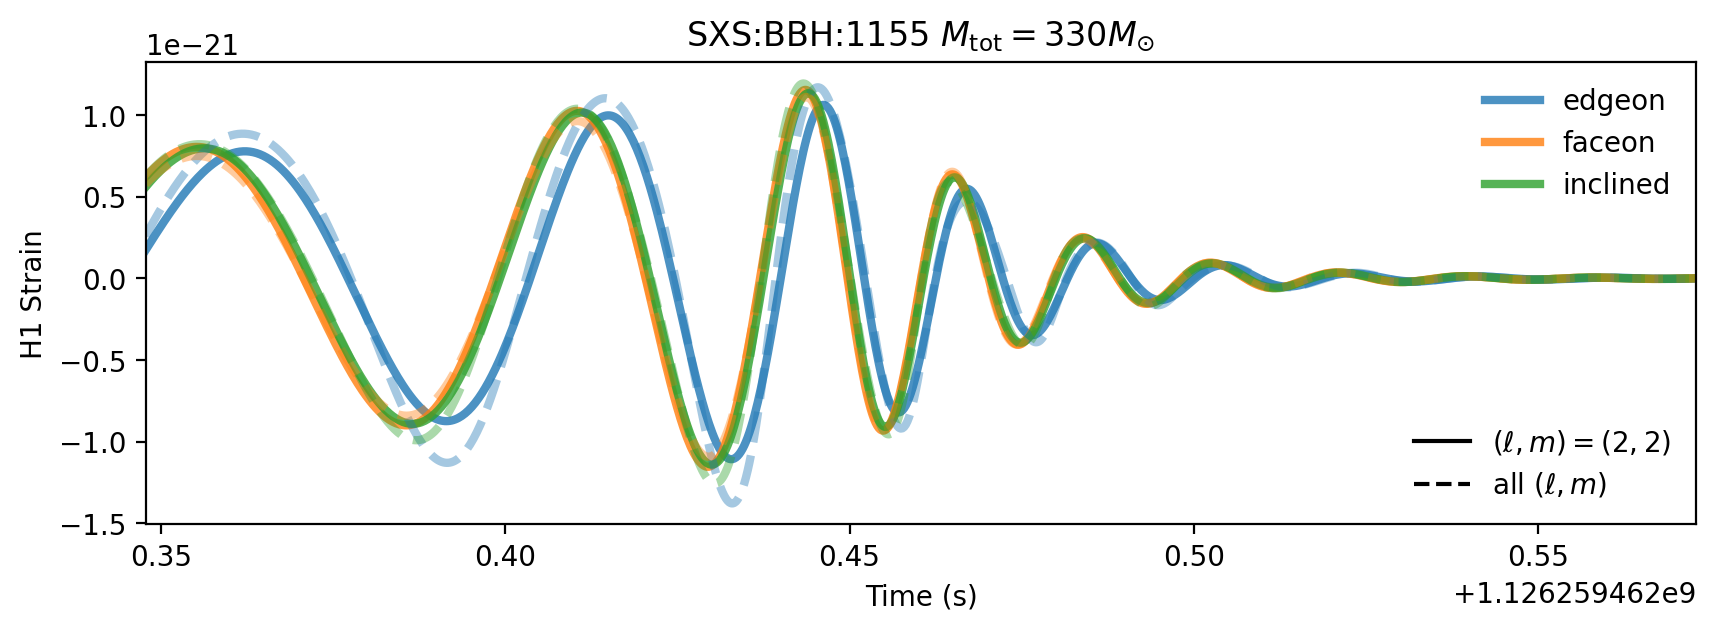

In [119]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (inc, df) in enumerate(heavy_dfs.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=inc)
for i, (inc, df) in enumerate(heavy_dfs_all.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.4, ls='--')

ax.set_xlim(np.median(df.index.values)-0.075, np.median(df.index.values)+0.15)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('SXS:BBH:1155 $M_{\mathrm{tot}} = 330 M_{\odot}$')

leg1 = ax.legend(frameon=False)
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k'), 
                  plt.Line2D([], [], color='k', ls='--')], 
                 ['$(\ell, m) = (2, 2)$',
                  'all $(\ell, m)$'], 
                 frameon=False, loc='lower right')